# XMatcher Jupyter API Guide / XMatcher Jupyter API 说明

**Release / 版本：V1.1.0**

This notebook shows how to use `MP500_xrd_database.pkl` after it has been built: load experimental XRD data, tune peak-detection and matching parameters, retrieve candidate phases, and interpret the result.

本 notebook 演示在已经构建好 `MP500_xrd_database.pkl` 之后，如何导入实验 XRD 数据、调整寻峰和匹配参数、检索候选物相，以及解释识别结果。

Assumed files / 默认文件：

- Database / 数据库: `MP500_xrd_database.pkl`
- Example XRD data / 示例 XRD 数据: `exp_data/TiO.csv`

Important / 重要说明：`XRDRetriever(database_path=...)` must point to the built peak database `.pkl`, not the raw ASE structure database `.db`.

`XRDRetriever(database_path=...)` 必须指向构建后的理论峰数据库 `.pkl`，不要直接传入原始结构数据库 `.db`。

## 1. Import APIs / 导入 API

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from XMatcher import XRDRetriever
from XMatcher.xrd_reader import XRDReader
from XMatcher.peak_detector import PeakDetector

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 2. Set Input Files / 设置输入文件

Change `DATABASE_PATH` and `XRD_FILE` to your own files.

把 `DATABASE_PATH` 和 `XRD_FILE` 改成你自己的文件路径。

In [2]:
DATABASE_PATH = Path("MP500_xrd_database.pkl")
XRD_FILE = Path("exp_data/TiO.csv")

assert DATABASE_PATH.exists(), f"Database not found / 找不到数据库: {DATABASE_PATH}"
assert XRD_FILE.exists(), f"XRD file not found / 找不到 XRD 文件: {XRD_FILE}"

DATABASE_PATH, XRD_FILE

(PosixPath('MP500_xrd_database.pkl'), PosixPath('exp_data/TiO.csv'))

## 3. Create Retriever / 创建检索器

`XRDRetriever` combines file reading, peak detection, element filtering, and peak matching.

`XRDRetriever` 会把读取文件、自动寻峰、元素过滤和峰匹配串起来。

Core parameters / 核心参数：

| Parameter | 中文 | Typical effect |
|---|---|---|
| `position_tolerance` | 峰位容差，单位为 2θ degree | Larger value is more tolerant to peak shifts but may increase false matches. 值越大越宽松，但误匹配可能增加。 |
| `min_peak_height` | 最小峰高，相对最强峰百分比 | Increase to ignore weak/noisy peaks. 调大可过滤弱峰和噪声。 |
| `min_peak_prominence` | 最小峰突出度，相对最强峰百分比 | Increase when background/noise creates false peaks. 背景或噪声导致假峰时调大。 |
| `n_peaks` | 使用的实验峰数量 | More peaks may improve specificity but can include impurity peaks. 更多峰更严格，但可能纳入杂峰。 |
| `max_shift` | 允许整体峰位偏移范围 | Useful for zero-shift/sample-displacement errors. 用于修正整体 2θ 偏移。 |
| `shift_step` | 整体偏移扫描步长 | Smaller is more precise but slower. 越小越精细但更慢。 |
| `min_matched_peaks` | 最少匹配峰数 | Increase to require stronger evidence. 调大可要求更多证据。 |
| `scoring_method` | 排序分数 | Usually keep `hybrid`. 通常保持 `hybrid`。 |

In [3]:
retriever = XRDRetriever(
    database_path=str(DATABASE_PATH),
    position_tolerance=0.20,
    min_peak_height=3.0,
    min_peak_prominence=2.0,
    n_peaks=20,
    scoring_method="hybrid",
    intensity_weight=0.15,
    position_weight=0.85,
    min_matched_peaks=2,
    max_shift=0.50,
    shift_step=0.02,
)

stats = retriever.get_database_statistics()
stats

{'total_entries': 100315,
 'unique_elements': ['Ac',
  'Ag',
  'Al',
  'As',
  'Au',
  'B',
  'Ba',
  'Be',
  'Bi',
  'Br',
  'C',
  'Ca',
  'Cd',
  'Ce',
  'Cl',
  'Co',
  'Cr',
  'Cs',
  'Cu',
  'Dy',
  'Er',
  'Eu',
  'F',
  'Fe',
  'Ga',
  'Gd',
  'Ge',
  'H',
  'He',
  'Hf',
  'Hg',
  'Ho',
  'I',
  'In',
  'Ir',
  'K',
  'Kr',
  'La',
  'Li',
  'Lu',
  'Mg',
  'Mn',
  'Mo',
  'N',
  'Na',
  'Nb',
  'Nd',
  'Ne',
  'Ni',
  'O',
  'Os',
  'P',
  'Pa',
  'Pb',
  'Pd',
  'Pm',
  'Pr',
  'Pt',
  'Rb',
  'Re',
  'Rh',
  'Ru',
  'S',
  'Sb',
  'Sc',
  'Se',
  'Si',
  'Sm',
  'Sn',
  'Sr',
  'Ta',
  'Tb',
  'Tc',
  'Te',
  'Th',
  'Ti',
  'Tl',
  'U',
  'V',
  'W',
  'Xe',
  'Y',
  'Zn',
  'Zr'],
 'n_unique_elements': 84,
 'unique_formulas': 87947,
 'wavelength': 'CuKa',
 'n_peaks_per_entry': 30,
 'two_theta_range': (10.0, 90.0),
 'schema_version': 2}

## 4. Read Experimental XRD Data / 读取实验 XRD 数据

`XRDReader.read_auto()` tries common delimiters automatically: comma, tab, whitespace, and semicolon.

`XRDReader.read_auto()` 会自动尝试常见分隔符：逗号、Tab、空格和分号。

Expected data format / 推荐数据格式：

- Column 1 / 第一列: `two_theta`, 2θ angle
- Column 2 / 第二列: `intensity`, intensity
- Header is allowed / 可以有表头
- Invalid, negative, duplicate, and unordered points are cleaned automatically / 会自动清理无效值、负强度、重复角度和乱序数据

In [4]:
reader = XRDReader()
xrd_data = reader.read_auto(XRD_FILE)

two_theta = xrd_data["two_theta"]
intensity = xrd_data["intensity"]

print(f"Points / 数据点数: {len(two_theta)}")
print(f"2θ range / 2θ 范围: {two_theta.min():.3f} - {two_theta.max():.3f}")
print(f"Intensity range / 强度范围: {intensity.min():.3f} - {intensity.max():.3f}")

pd.DataFrame({"two_theta": two_theta[:8], "intensity": intensity[:8]})

Points / 数据点数: 3500
2θ range / 2θ 范围: 10.000 - 80.000
Intensity range / 强度范围: 0.113 - 100.000


,two_theta,intensity
0,10.000000,1.386729
1,10.020006,0.944102
2,10.040011,0.324414
3,10.060017,0.112785
4,10.080023,1.694707
5,10.100029,1.702809
6,10.120034,0.710258
7,10.140040,1.004075


If automatic reading fails, use `read_csv()` with explicit columns and delimiter.

如果自动读取失败，可以用 `read_csv()` 明确指定列号和分隔符。列号从 0 开始。

In [5]:
# Example only / 示例：按你的文件格式修改
# xrd_data = reader.read_csv(
#     "your_xrd_file.txt",
#     two_theta_col=0,
#     intensity_col=1,
#     delimiter="\t",      # comma: ","; tab: "\t"; whitespace: r"\s+"; semicolon: ";"
#     skip_rows=0,
#     header="infer",      # use None if there is no header / 没有表头时用 None
# )

## 5. Plot Raw Spectrum / 绘制原始谱图

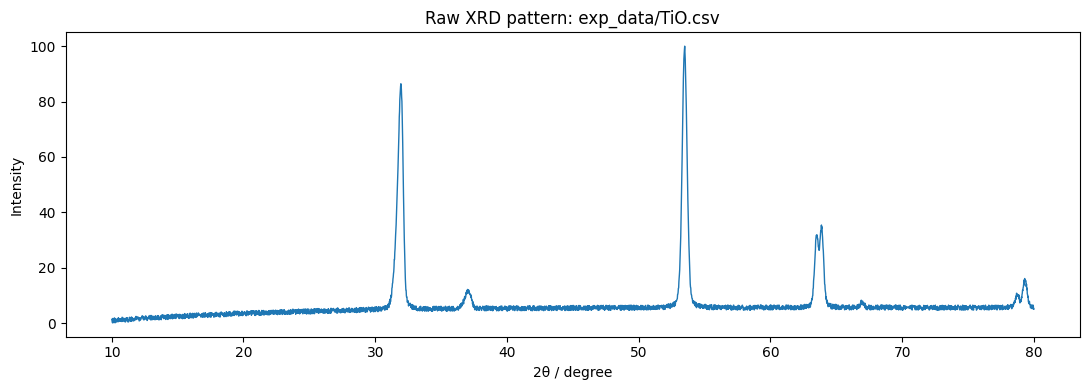

In [7]:
plt.figure(figsize=(11, 4))
plt.plot(two_theta, intensity, lw=1.0)
plt.xlabel("2θ / degree")
plt.ylabel("Intensity")
plt.title(f"Raw XRD pattern: {XRD_FILE}")
plt.tight_layout()
plt.show()

## 6. Detect Peaks / 自动寻峰

The retriever preprocesses the spectrum before peak detection: normalize intensity, remove baseline, smooth, then detect peaks.

检索器寻峰前会预处理谱图：强度归一化、扣背景、平滑，然后寻峰。

If too many noise peaks are detected / 如果噪声峰太多：increase `min_peak_height` or `min_peak_prominence`.

If real weak peaks are missing / 如果真实弱峰漏检：decrease `min_peak_height` or `min_peak_prominence`.

In [8]:
peaks = retriever.detect_peaks(two_theta, intensity)
peak_table = pd.DataFrame(peaks)

print(f"Detected peaks / 检测到峰数: {len(peaks)}")
peak_table[["two_theta", "intensity", "prominence", "width"]].head(20)

Detected peaks / 检测到峰数: 8


,two_theta,intensity,prominence,width
0,53.484650,100.000000,94.162627,0.432382
1,31.945977,86.979790,81.746346,0.494084
2,63.884959,32.016061,29.994525,0.726164
3,63.511718,28.800726,5.536993,0.173319
4,79.338283,11.434949,10.636704,0.421676
5,37.091665,7.936813,7.279664,0.616136
6,78.711464,6.127805,2.909061,0.253989
7,66.878149,3.520995,3.008381,0.362109


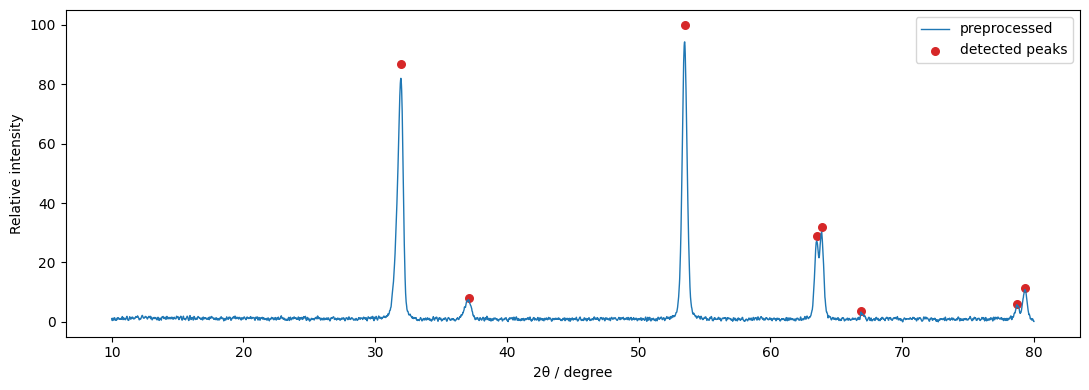

In [10]:
processed_two_theta, processed_intensity = retriever.peak_detector.preprocess_spectrum(two_theta, intensity)

plt.figure(figsize=(11, 4))
plt.plot(processed_two_theta, processed_intensity, lw=1.0, label="preprocessed")

if peaks:
    peak_pos = np.array([p["two_theta"] for p in peaks])
    peak_int = np.array([p["intensity"] for p in peaks])
    plt.scatter(peak_pos, peak_int, s=30, color="tab:red", label="detected peaks")

plt.xlabel("2θ / degree")
plt.ylabel("Relative intensity")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Retrieve Candidate Phases / 检索候选物相

This section performs full-database retrieval by default.

本节默认执行全库检索。

Full search can be slow on a large database such as `MP500_xrd_database.pkl`, because every candidate structure needs peak-level matching.

对于 `MP500_xrd_database.pkl` 这种较大的数据库，全库检索会比较慢，因为每个候选结构都要做峰级匹配。

- `elements=None`: search all database entries / 搜索全库
- `elements=["Ti", "O"]`, `element_filter_mode="contains"`: optional faster search; candidates must contain Ti and O, but may contain extra elements / 可选加速检索；候选必须包含 Ti 和 O，但可以有额外元素
- `elements=["Ti", "O"]`, `element_filter_mode="exact"`: optional strict chemistry search; candidates must contain exactly Ti and O / 可选严格元素检索；候选元素必须正好是 Ti 和 O

In [11]:
QUERY_ELEMENTS = None            # None means full database search / None 表示全库检索
ELEMENT_FILTER_MODE = "contains" # Used only when QUERY_ELEMENTS is not None / 仅在 QUERY_ELEMENTS 不是 None 时生效
TOP_N = 10

results = retriever.retrieve_from_file(
    XRD_FILE,
    elements=QUERY_ELEMENTS,
    top_n=TOP_N,
    element_filter_mode=ELEMENT_FILTER_MODE,
)

retriever.print_results(results, max_results=TOP_N)


Top 5 Matches
 1. score=60.92 weighted=54.52 fom=60.61 matched=8 shift=+0.000 formula=ErN2U mpid=mp-1225410.cif
 2. score=50.15 weighted=40.02 fom=48.25 matched=8 shift=+0.160 formula=Ho3Zr mpid=mp-976029.cif
 3. score=47.72 weighted=50.22 fom=24.84 matched=8 shift=-0.220 formula=Cs2F5ORbZr mpid=mp-42022.cif
 4. score=47.24 weighted=39.71 fom=37.23 matched=8 shift=-0.100 formula=BiNa mpid=mp-22924.cif
 5. score=45.51 weighted=41.52 fom=30.52 matched=8 shift=-0.180 formula=N2O5Y6 mpid=mp-780722.cif


In [12]:
result_table = pd.DataFrame(results)

display_cols = [
    "entry_id", "mpid", "formula", "elements", "spacegroup", "spacegroup_symbol",
    "score", "weighted_score", "fom", "experimental_coverage",
    "precision", "recall", "n_matched_peaks", "mean_abs_error", "estimated_shift",
]

result_table[display_cols] if not result_table.empty else result_table

,entry_id,mpid,formula,elements,spacegroup,spacegroup_symbol,score,weighted_score,fom,experimental_coverage,precision,recall,n_matched_peaks,mean_abs_error,estimated_shift
0,42049,mp-1225410.cif,ErN2U,"[Er, N, U]",123,P4/mmm,60.918852,54.520821,60.614944,100.0,1.0,0.320000,8,0.038310,0.00
1,98752,mp-976029.cif,Ho3Zr,"[Ho, Zr]",139,I4/mmm,50.150951,40.018617,48.253023,100.0,1.0,0.266667,8,0.100914,0.16
2,69302,mp-42022.cif,Cs2F5ORbZr,"[Cs, F, O, Rb, Zr]",107,I4mm,47.719279,50.223739,24.839766,100.0,1.0,0.266667,8,0.042739,-0.22
3,59766,mp-22924.cif,BiNa,"[Bi, Na]",123,P4/mmm,47.238427,39.711121,37.228074,100.0,1.0,0.320000,8,0.113024,-0.10
4,94707,mp-780722.cif,N2O5Y6,"[N, O, Y]",12,C2/m,45.508437,41.521513,30.523631,100.0,1.0,0.266667,8,0.091926,-0.18


## 8. Interpret Results / 结果解释

| Field | 中文 | Meaning |
|---|---|---|
| `score` | 总分 | Main ranking score. Higher is better. 主要排序分数，越高越好。 |
| `weighted_score` | 峰位/强度匹配分 | Peak position and intensity assignment quality. 峰位和强度的匹配质量。 |
| `fom` | 理论峰覆盖度 | Percentage of theoretical peak intensity explained by matched peaks. 匹配到的理论峰强度占比。 |
| `experimental_coverage` | 实验峰覆盖度 | Percentage of experimental peak intensity explained by matched peaks. 匹配到的实验峰强度占比。 |
| `precision` | 实验峰匹配比例 | Matched experimental peaks / all experimental peaks. 匹配实验峰数 / 实验峰总数。 |
| `recall` | 理论峰匹配比例 | Matched database peaks / all database peaks. 匹配理论峰数 / 理论峰总数。 |
| `n_matched_peaks` | 匹配峰数 | Number of paired experimental/theoretical peaks. 匹配上的峰对数量。 |
| `mean_abs_error` | 平均峰位误差 | Mean absolute 2θ error after shift correction. 修正整体偏移后的平均 2θ 误差。 |
| `estimated_shift` | 估计整体偏移 | Applied global shift to theoretical peaks. 对理论峰施加的整体 2θ 偏移。 |

Practical judgment / 实用判断：

- Good match / 较可信：high `score`, high `n_matched_peaks`, low `mean_abs_error`, small `estimated_shift`.
- Suspicious match / 需要谨慎：only 2 peaks matched, large shift, or high score caused by very few strong peaks.
- Mixed phase / 混相：top candidates may each explain different subsets of peaks; inspect `peak_matches` and residual unmatched peaks.

## 9. Inspect Best Match / 查看最佳匹配的峰对

In [13]:
if results:
    best = results[0]
    print("Best candidate / 最佳候选:")
    print({k: best[k] for k in ["entry_id", "mpid", "formula", "score", "n_matched_peaks", "mean_abs_error", "estimated_shift"]})

    match_table = pd.DataFrame(best["peak_matches"])
    display(match_table)
else:
    print("No results / 无结果")

Best candidate / 最佳候选:
{'entry_id': 42049, 'mpid': 'mp-1225410.cif', 'formula': 'ErN2U', 'score': 60.91885248731634, 'n_matched_peaks': 8, 'mean_abs_error': 0.038310174809036646, 'estimated_shift': 0.0}


,exp_index,db_index,exp_two_theta,db_two_theta,db_two_theta_unshifted,delta,exp_intensity,db_intensity,cost
0,0,2,31.945977,31.958734,31.958734,-0.012757,93.262956,100.000000,0.064323
1,1,3,37.091665,36.978065,36.978065,0.113599,28.172349,67.089409,0.541173
2,2,8,53.484650,53.497896,53.497896,-0.013247,100.000000,55.691020,0.122761
3,3,12,63.511718,63.502342,63.502342,0.009376,53.666308,55.126808,0.042038
4,4,13,63.884959,63.870439,63.870439,0.014520,56.582736,38.662116,0.088592
5,5,14,66.878149,66.813948,66.813948,0.064201,18.764314,40.004249,0.304715
6,6,17,78.711464,78.728205,78.728205,-0.016741,24.754403,22.629845,0.074335
7,7,18,79.338283,79.400323,79.400323,-0.062040,33.815602,15.837141,0.290639


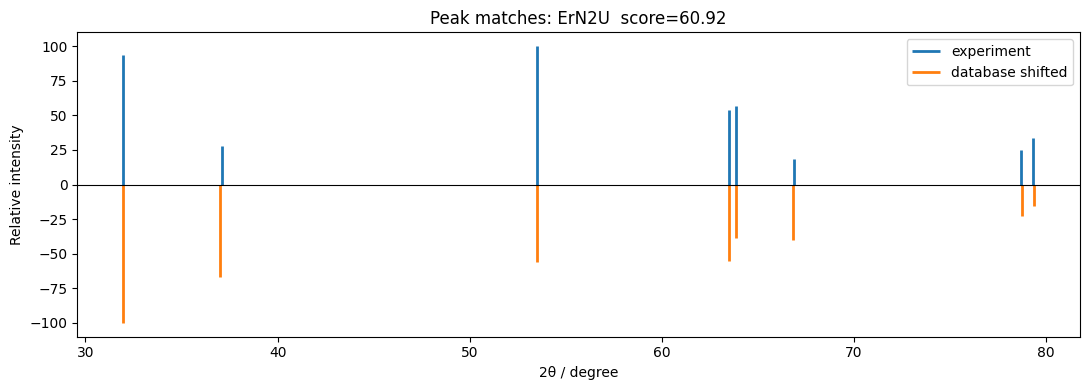

In [15]:
if results and best["peak_matches"]:
    m = pd.DataFrame(best["peak_matches"])

    plt.figure(figsize=(11, 4))
    plt.vlines(m["exp_two_theta"], 0, m["exp_intensity"], color="tab:blue", lw=2, label="experiment")
    plt.vlines(m["db_two_theta"], 0, -m["db_intensity"], color="tab:orange", lw=2, label="database shifted")
    plt.axhline(0, color="black", lw=0.8)
    plt.xlabel("2θ / degree")
    plt.ylabel("Relative intensity")
    plt.title(f"Peak matches: {best['formula']}  score={best['score']:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 10. Parameter Tuning Recipes / 参数调整建议

Use the following recipes when the initial result is poor.

当初始识别结果不好时，可以按下面方式调参。

| Symptom / 现象 | What to change / 调整项 | Why / 原因 |
|---|---|---|
| Too many false/noisy peaks / 噪声峰太多 | Increase `min_peak_height` from `3` to `5-10`; increase `min_peak_prominence` from `2` to `5-10` | Stronger threshold filters noise. 更高阈值可过滤噪声。 |
| Missing weak real peaks / 弱峰漏检 | Decrease `min_peak_height` to `1-2`; decrease `min_peak_prominence` to `0.5-1.5` | Lower threshold keeps weak peaks. 降低阈值保留弱峰。 |
| Peaks are slightly shifted / 峰整体偏移 | Increase `max_shift` to `0.8-1.0`; use `shift_step=0.01` | Allows zero-offset/sample-displacement correction. 允许修正零点或样品位移误差。 |
| Too many candidates / 候选太多 | Provide `elements`; use `element_filter_mode="exact"`; increase `min_matched_peaks` | Stronger chemical and peak-count constraints. 增强化学和峰数约束。 |
| Suspected impurities / 怀疑有杂相 | Use `element_filter_mode="contains"`; increase `n_peaks`; inspect unmatched strong peaks | Allows extra elements and mixed-phase evidence. 允许额外元素并观察未匹配强峰。 |
| Slow search / 检索慢 | Provide `elements`; reduce `top_n`; increase `shift_step`; reduce `n_peaks` | Reduces candidate count and shift scan cost. 减少候选和偏移扫描成本。 |

In [16]:
# Example: stricter peak detection with full-database retrieval / 示例：更严格寻峰 + 全库检索
strict_retriever = XRDRetriever(
    database_path=str(DATABASE_PATH),
    position_tolerance=0.20,
    min_peak_height=8.0,
    min_peak_prominence=6.0,
    n_peaks=15,
    min_matched_peaks=3,
    max_shift=0.50,
    shift_step=0.02,
)

strict_results = strict_retriever.retrieve_from_file(
    XRD_FILE,
    elements=QUERY_ELEMENTS,
    top_n=5,
    element_filter_mode=ELEMENT_FILTER_MODE,
)

pd.DataFrame(strict_results)[display_cols] if strict_results else pd.DataFrame()

,entry_id,mpid,formula,elements,spacegroup,spacegroup_symbol,score,weighted_score,fom,experimental_coverage,precision,recall,n_matched_peaks,mean_abs_error,estimated_shift
0,59,mp-10044.cif,AsB,"[As, B]",216,F-43m,70.727931,67.785790,65.033465,100.0,1.0,0.571429,4,0.029552,-0.224891
1,60419,mp-24155.cif,H2Zr,"[H, Zr]",225,Fm-3m,69.893532,67.062253,63.337441,100.0,1.0,0.571429,4,0.031588,-0.230405
2,6617,mp-1062345.cif,Li2N,"[Li, N]",225,Fm-3m,66.726800,44.779446,86.205879,100.0,1.0,0.571429,4,0.129679,0.080000
3,202,mp-1008677.cif,O2Ti,"[O, Ti]",225,Fm-3m,66.618990,48.755660,79.882192,100.0,1.0,0.571429,4,0.110478,0.000000
4,437,mp-1009832.cif,CTa,"[C, Ta]",216,F-43m,61.988461,49.155328,63.847592,100.0,1.0,0.571429,4,0.104929,0.000000


In [17]:
# Example: more tolerant full-database search / 示例：更宽松的全库检索，适合峰位可能有偏移的数据
tolerant_retriever = XRDRetriever(
    database_path=str(DATABASE_PATH),
    position_tolerance=0.30,
    min_peak_height=2.0,
    min_peak_prominence=1.0,
    n_peaks=25,
    min_matched_peaks=2,
    max_shift=1.00,
    shift_step=0.01,
)

tolerant_results = tolerant_retriever.retrieve_from_file(
    XRD_FILE,
    elements=QUERY_ELEMENTS,
    top_n=5,
    element_filter_mode=ELEMENT_FILTER_MODE,
)

pd.DataFrame(tolerant_results)[display_cols] if tolerant_results else pd.DataFrame()

""


## 11. Manual Peak Input / 手动输入峰位

If you already have peak positions and relative intensities from another program, bypass file reading and automatic peak detection.

如果你已经用其他软件得到峰位和相对强度，可以跳过文件读取和自动寻峰。

In [18]:
manual_peak_positions = [27.4, 36.1, 41.2, 54.3, 56.6]
manual_peak_intensities = [100, 60, 35, 25, 20]

manual_results = retriever.retrieve_from_peaks(
    manual_peak_positions,
    manual_peak_intensities,
    elements=QUERY_ELEMENTS,
    top_n=10,
    element_filter_mode=ELEMENT_FILTER_MODE,
)

pd.DataFrame(manual_results)[display_cols] if manual_results else pd.DataFrame()

,entry_id,mpid,formula,elements,spacegroup,spacegroup_symbol,score,weighted_score,fom,experimental_coverage,precision,recall,n_matched_peaks,mean_abs_error,estimated_shift
0,61552,mp-2657.cif,O8Ti4,"[O, Ti]",136,P4_2/mnm,48.340809,53.806037,24.871418,100.0,1.0,0.166667,5,0.015592,-0.010696
1,88117,mp-758265.cif,Cu4F12Li2,"[Cu, F, Li]",136,P4_2/mnm,47.476417,54.883508,20.373905,100.0,1.0,0.166667,5,0.011295,-0.044636
2,93849,mp-776957.cif,FFe10O19,"[F, Fe, O]",38,Amm2,46.855178,46.684856,30.601087,100.0,1.0,0.166667,5,0.046908,0.082312
3,90077,mp-764777.cif,Co6F6O6,"[Co, F, O]",31,Pmn2_1,45.912018,44.849010,30.210989,100.0,1.0,0.166667,5,0.057250,-0.271805
4,89333,mp-760396.cif,Al2O8Ta2,"[Al, O, Ta]",109,I4_1md,45.006068,44.576079,27.600553,100.0,1.0,0.166667,5,0.057693,0.280460
5,89135,mp-759720.cif,Cu8Li8O16,"[Cu, Li, O]",2,P-1,44.810340,49.841605,19.049836,100.0,1.0,0.166667,5,0.026911,-0.028909
6,88923,mp-759689.cif,FO11V6,"[F, O, V]",38,Amm2,44.721650,41.300923,31.565227,100.0,1.0,0.166667,5,0.076654,-0.210528
7,30875,mp-1209941.cif,N2Nb10Si6,"[N, Nb, Si]",193,P6_3/mcm,44.458813,47.954931,20.708092,100.0,1.0,0.166667,5,0.035229,0.086849
8,86563,mp-755866.cif,F2Mn6O10,"[F, Mn, O]",38,Amm2,44.240784,40.106818,31.753499,100.0,1.0,0.166667,5,0.082808,0.320000
9,87730,mp-757624.cif,La8O18Sr6,"[La, O, Sr]",9,Cc,44.074540,50.142829,16.145333,100.0,1.0,0.166667,5,0.025673,-0.410101


## 12. Search Helpers / 辅助查询

Use these helpers to inspect the database without matching a spectrum.

可以用这些方法直接查看数据库条目。

In [19]:
# Search database entries by exact formula / 按精确化学式查询
formula_hits = retriever.search_by_formula("TiO")
print(f"Formula hits / 化学式命中数: {len(formula_hits)}")
pd.DataFrame(formula_hits).head()

Formula hits / 化学式命中数: 0


""


In [20]:
# Search entries by elements / 按元素查询
element_hits = retriever.search_by_elements(["Ti", "O"], element_filter_mode="contains")
print(f"Element hits / 元素命中数: {len(element_hits)}")
pd.DataFrame(element_hits).head()

Element hits / 元素命中数: 3659


,entry_id,mpid,formula,elements,n_atoms,spacegroup_number,spacegroup_symbol,peaks
0,202,mp-1008677.cif,O2Ti,"[O, Ti]",3,225,Fm-3m,"{'positions': [32.029256834390615, 53.55341985..."
1,641,mp-1012865.cif,Li2O26P6Ti6,"[Li, O, P, Ti]",40,11,P2_1/m,"{'positions': [19.11608560593911, 16.295666534..."
2,717,mp-1013874.cif,Na2O26P6Ti6,"[Na, O, P, Ti]",40,11,P2_1/m,"{'positions': [19.174010893355167, 27.83767391..."
3,2105,mp-1025200.cif,Eu2O4Ti,"[Eu, O, Ti]",7,139,I4/mmm,"{'positions': [32.56204667076271, 31.642101055..."
4,3227,mp-1031147.cif,Mg6O8SiTi,"[Mg, O, Si, Ti]",16,123,P4/mmm,"{'positions': [41.878358629993905, 60.25791232..."


## 13. AutoMix Multi-phase Identification / AutoMix 自动多相识别

Use AutoMix when one single-phase candidate cannot explain the main experimental peaks. It searches combinations of up to three leading single-phase candidates and performs non-negative fitting of the detected peak intensities.

当单相候选无法解释主要实验峰时，可使用 AutoMix。它从前列单相候选中搜索最多三个相的组合，并对检测峰强度进行非负拟合。

Important / 重要：`relative_contribution` is a relative fitted diffraction contribution, **not** a mass fraction or weight percentage. `candidate_pool` is the number of leading single-phase candidates used to build combinations. Keep it moderate: a large pool causes the number of combinations to grow quickly, slows the calculation, and can add near-duplicate alternatives.

`relative_contribution` 表示相对拟合衍射贡献，**不等同于质量分数或重量百分比**。`candidate_pool` 是用于组成组合的前列单相候选数量。请保持适中：数值过大会使组合数快速增长、计算变慢，并可能引入近似重复结果。

Recommended workflow / 推荐流程：first inspect normal single-phase results, then run AutoMix, inspect the ranked combinations and peak attribution, and finally use the App PDF full-peak module with CIF files for confirmation.

先查看常规单相结果，再运行 AutoMix，检查组合排序和峰归属，最后使用 App 的 PDF 全峰对比模块及 CIF 文件完成确认。

In [ ]:
# AutoMix uses the same detected peaks as single-phase retrieval / AutoMix 使用与单相检索相同的检测峰
peak_positions = [peak["two_theta"] for peak in peaks]
peak_intensities = [peak["intensity"] for peak in peaks]

MAX_PHASES = 3       # Usually start with 2 / 通常建议先从 2 开始
CANDIDATE_POOL = 12  # Keep moderate / 保持适中，过大会显著增加组合数

automix_result = retriever.retrieve_multiple_phases_from_peaks(
    peak_positions,
    peak_intensities,
    elements=QUERY_ELEMENTS,
    element_filter_mode=ELEMENT_FILTER_MODE,
    max_phases=MAX_PHASES,
    candidate_pool=CANDIDATE_POOL,
    top_n=10,
)

print(automix_result.get("disclaimer", ""))
print(f"Candidates / 候选数: {automix_result.get('candidate_count', 0)}")
print(f"Combinations tested / 已测试组合数: {automix_result.get('combinations_tested', 0)}")

In [ ]:
# Summarize ranked effective phase combinations / 汇总排序后的有效物相组合
combination_rows = []
for rank, combination in enumerate(automix_result.get("results", []), start=1):
    phases = combination.get("phases", [])
    label = " + ".join(
        f"{phase.get('formula', '-')} ({phase.get('relative_contribution', 0):.1f}%)"
        for phase in phases
    )
    unexplained = sum(not peak.get("assigned_formula") for peak in combination.get("peak_attribution", []))
    combination_rows.append({
        "rank": rank,
        "phases / 物相": label,
        "score": combination.get("score"),
        "explained_intensity_percent / 已解释强度%": combination.get("explained_intensity_percent"),
        "unexplained_peaks / 未解释峰数": unexplained,
    })

automix_table = pd.DataFrame(combination_rows)
display(automix_table)

# Inspect attribution of the best combination / 查看最佳组合的峰归属和残峰
if automix_result.get("results"):
    best_combination = automix_result["results"][0]
    attribution_table = pd.DataFrame(best_combination.get("peak_attribution", []))
    display(attribution_table)
else:
    print("No usable AutoMix combination / 没有可用的 AutoMix 组合")

## 14. Common Problems / 常见问题

### No matches found / 没有识别结果

- Lower `min_peak_height` and `min_peak_prominence` if too few peaks were detected.
- Increase `position_tolerance` or `max_shift` if peaks are shifted.
- Use `elements=None` once to check whether the element filter is too strict.

- 如果检测到的峰太少，降低 `min_peak_height` 和 `min_peak_prominence`。
- 如果峰位整体偏移，增大 `position_tolerance` 或 `max_shift`。
- 可以先用 `elements=None` 搜全库，确认是不是元素过滤太严格。

### Wrong phase ranked first / 第一名看起来不对

- Inspect `peak_matches`, especially `n_matched_peaks`, `mean_abs_error`, and `estimated_shift`.
- Compare the top 5-10 candidates, not only the first result.
- If the sample may be mixed phase, a single database entry may not explain all peaks.

- 查看 `peak_matches`，重点看 `n_matched_peaks`、`mean_abs_error` 和 `estimated_shift`。
- 不要只看第一名，建议比较前 5-10 个候选。
- 如果样品是混相，单一数据库结构可能无法解释所有峰。

### Data file cannot be read / 数据文件读不进来

- Use `reader.read_csv()` with explicit `delimiter`, `skip_rows`, `header`, and column indexes.
- Ensure the first two selected columns are numeric 2θ and intensity.

- 使用 `reader.read_csv()` 明确指定 `delimiter`、`skip_rows`、`header` 和列号。
- 确保选中的两列分别是数值型 2θ 和强度。